In [1]:
# Librerías para el manejo de datos #
import os             # Interactúa con el sistema operativo (archivos, rutas)
import numpy as np    # Cálculo numérico con arrays
import pandas as pd   # Manipulación y análisis de datos
import io             # Manejo de flujos en memoria

In [2]:
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [3]:
# cargar los datos #
data = pd.read_csv("../data/raw/dataset_clasificacion.csv", sep=";")      # El separador es ";" porque en el archivo .csv los valores están separados por punto y coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


## 1. Identificación de tipos de variables
En esta sección se identifican las variables numéricas y categóricas de la base de clasificación.

In [4]:
variables_numericas = data.select_dtypes(include="number").columns.tolist()
variables_categoricas = data.select_dtypes(exclude="number").columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']

Variables categóricas:
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


**Interpretación:**  
La base de clasificación contiene variables numéricas y categóricas. Las variables numéricas permiten realizar medidas descriptivas, histogramas, correlaciones y detección de valores atípicos. Las variables categóricas permiten analizar frecuencias, relaciones con la variable objetivo y comparaciones entre grupos.

In [5]:
# Dimensiones del DataFrame #
data.shape
# Información general del DataFrame #
data.info()
# Descripción de los datos #
data.describe()
# Descripción de los datos con las variables categóricas #
data.describe(include = "object")
# Valores nulos por columna #
data.isnull().sum()
# Porcentaje de valores nulos por columna #
(data.isnull().sum()/len(data))*100

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    str    
 6   pc      335 non-null    str    
 7   pcc     396 non-null    str    
 8   ba      396 non-null    str    
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    str    
 19  dm      398 non-null    str    
 20  cad     398 non-null    str    
 21  appet   399 non-null    str    
 22  pe      399 n

C:\Users\Lenovo ThinkBook\AppData\Local\Temp\ipykernel_10320\2229018293.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include = "object")


age       2.25
bp        3.00
sg       11.75
al       11.50
su       12.25
rbc      38.00
pc       16.25
pcc       1.00
ba        1.00
bgr      11.00
bu        4.75
sc        4.25
sod      21.75
pot      22.00
hemo     13.00
pcv      17.75
wbcc     26.50
rbcc     32.75
htn       0.50
dm        0.50
cad       0.50
appet     0.25
pe        0.25
ane       0.25
class     0.00
dtype: float64

## 2. Análisis descriptivo de variables numéricas
En esta sección se calculan medidas descriptivas de tendencia central y dispersión para las variables numéricas de la base de clasificación.

In [6]:
data[variables_numericas].describe().T[["mean", "50%", "std", "min", "max"]]

,mean,50%,std,min,max
age,51.483376,55.00,17.169714,2.000,90.000
bp,76.469072,80.00,13.683637,50.000,180.000
sg,1.017408,1.02,0.005717,1.005,1.025
al,1.016949,0.00,1.352679,0.000,5.000
su,0.450142,0.00,1.099191,0.000,5.000
bgr,148.036517,121.00,79.281714,22.000,490.000
bu,57.425722,42.00,50.503006,1.500,391.000
sc,3.072454,1.30,5.741126,0.400,76.000
sod,137.528754,138.00,10.408752,4.500,163.000
pot,4.627244,4.40,3.193904,2.500,47.000


**Interpretación:**  
En la tabla anterior, `mean` corresponde a la media, `50%` corresponde a la mediana y `std` corresponde a la desviación estándar. Estas medidas permiten resumir el comportamiento general de las variables numéricas y comparar su nivel de dispersión.

## 3. Distribución de las variables numéricas
En esta sección se visualiza la distribución de las variables numéricas mediante histogramas.

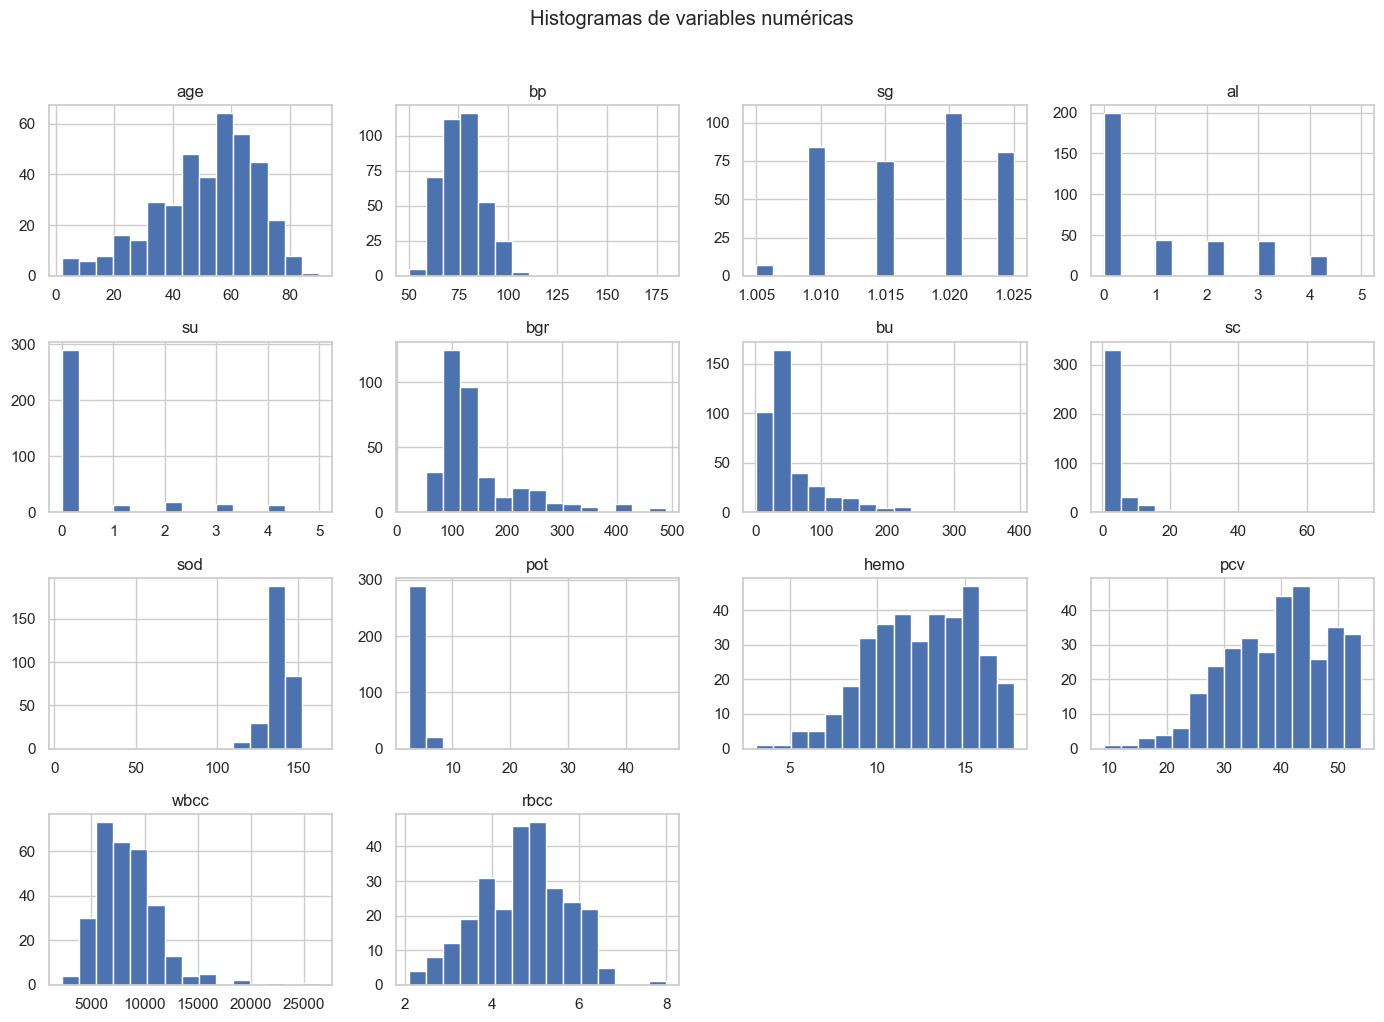

In [7]:
data[variables_numericas].hist(figsize=(14, 10), bins=15)
plt.suptitle("Histogramas de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:**  
Los histogramas permiten observar la forma de la distribución de cada variable numérica, identificar posibles asimetrías y detectar concentraciones o dispersiones de los valores. Esta visualización complementa las medidas descriptivas calculadas anteriormente.

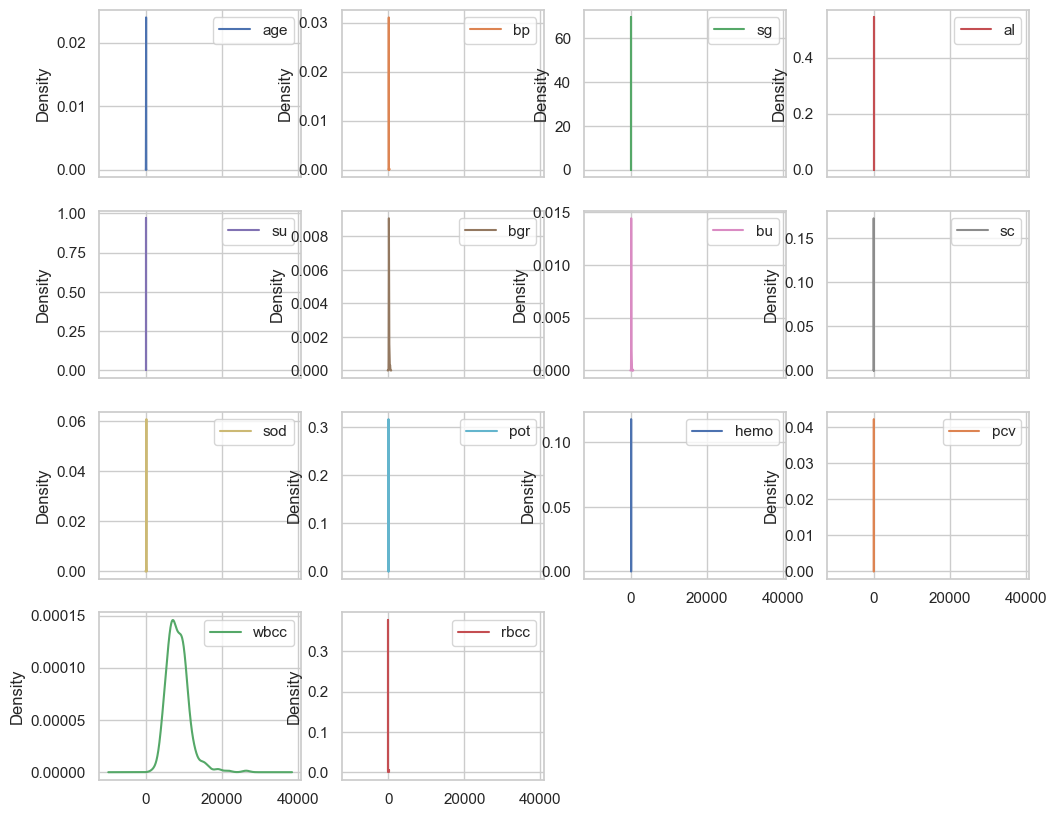

In [8]:
import numpy as np
data_num = data.select_dtypes(include=np.number)
data_num.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10))
plt.show()

## 4. Identificación de valores atípicos
En esta sección se utilizan boxplots para identificar posibles valores atípicos en las variables numéricas de la base de clasificación.

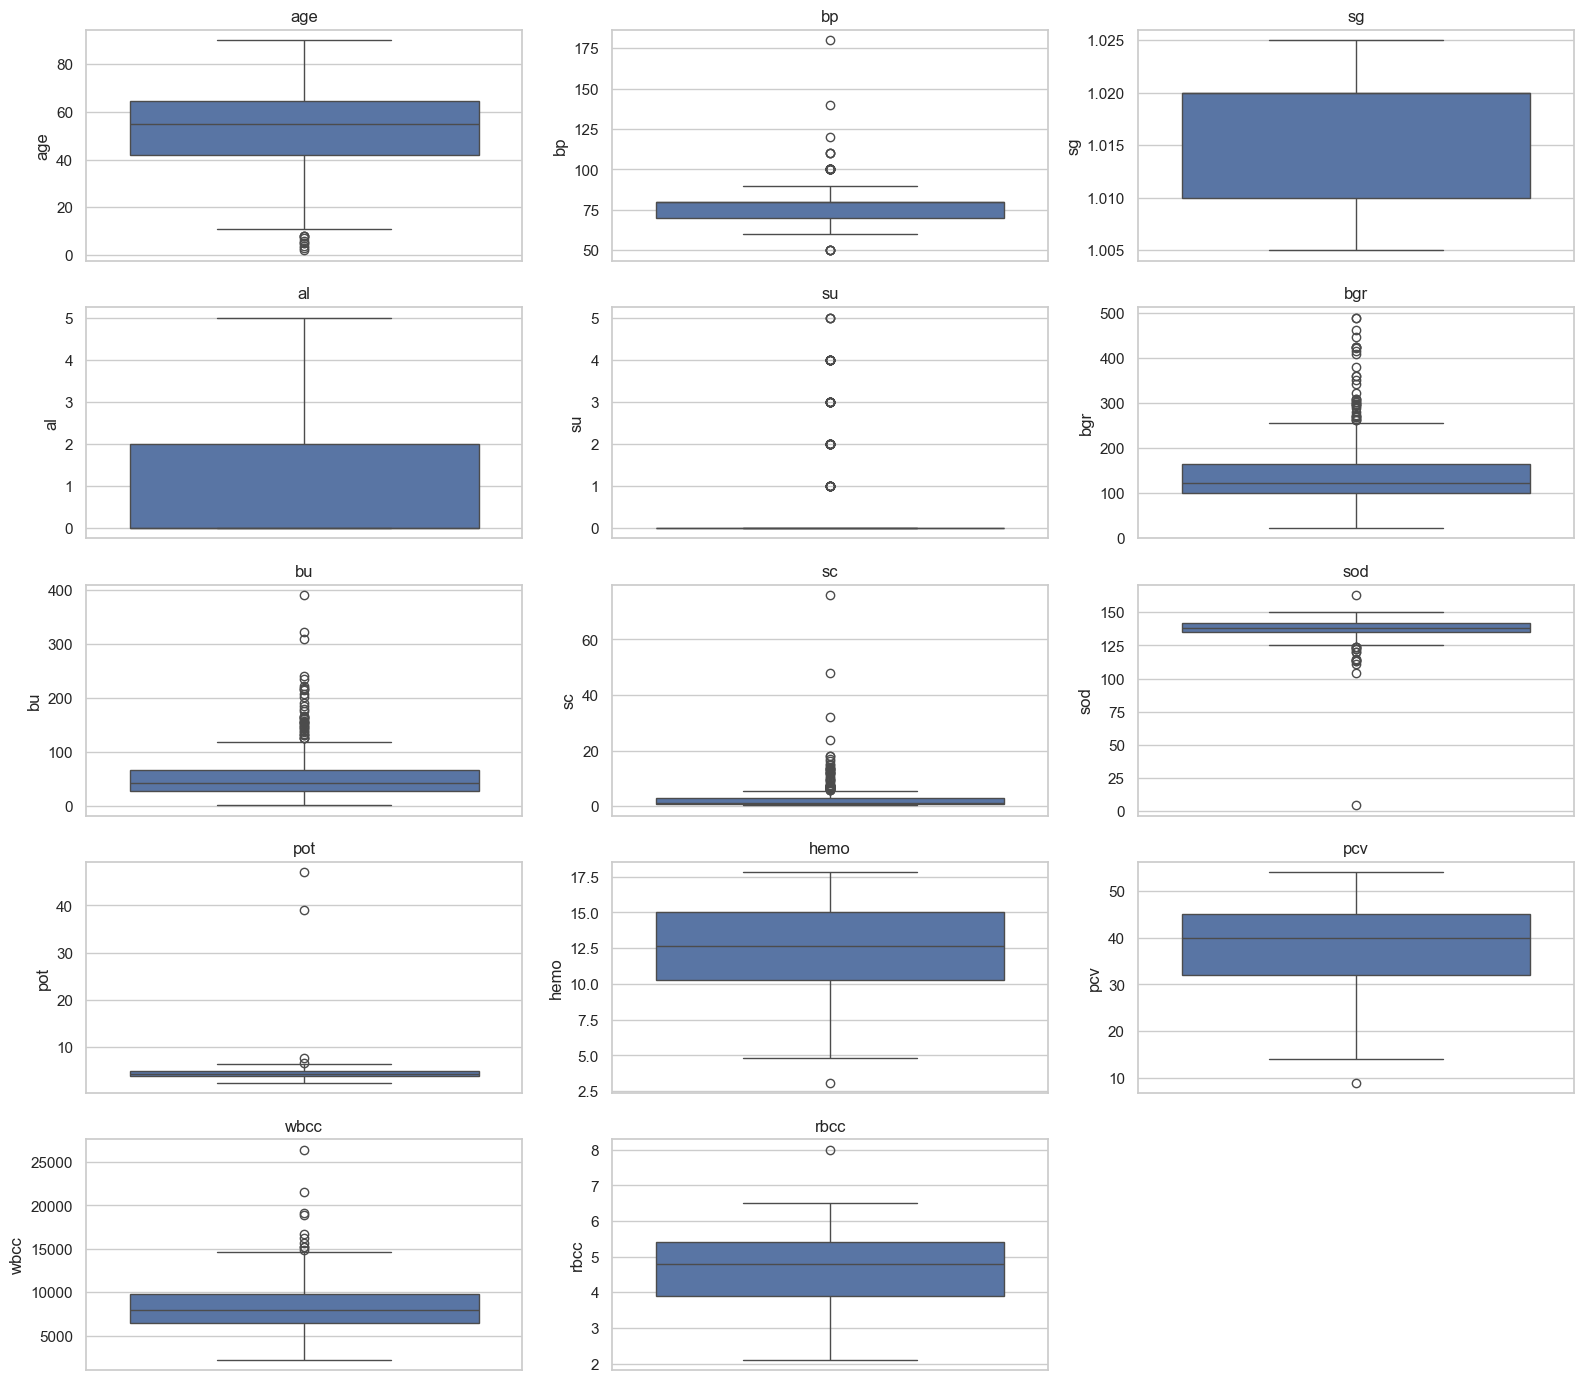

In [9]:
plt.figure(figsize=(16, 14))

for i, col in enumerate(variables_numericas, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Interpretación:**  
Los boxplots permiten identificar posibles valores atípicos en las variables numéricas. Los puntos que aparecen alejados de la caja y los bigotes pueden considerarse observaciones extremas. Estas observaciones deben analizarse con cuidado antes de decidir si se eliminan, transforman o conservan.

## 5. Análisis de correlación
En esta sección se analiza la correlación entre las variables numéricas de la base de clasificación mediante una matriz de correlación y un mapa de calor.

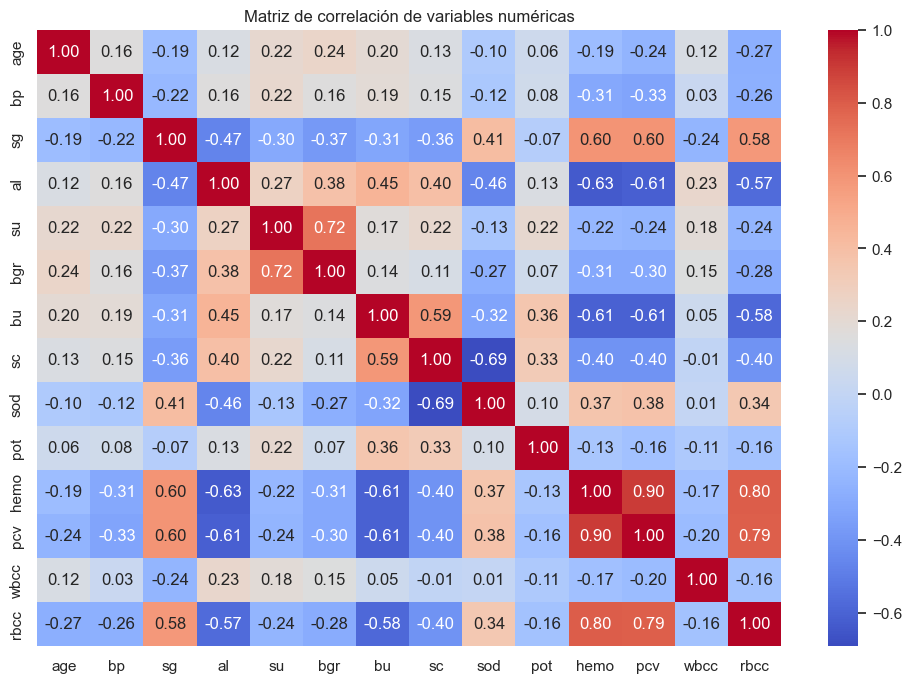

In [10]:
corr = data[variables_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

**Interpretación:**  
La matriz de correlación permite identificar relaciones lineales entre variables numéricas. Los valores cercanos a 1 indican correlación positiva fuerte, los valores cercanos a -1 indican correlación negativa fuerte y los valores cercanos a 0 indican poca o ninguna relación lineal.

## 6. Relaciones entre variables y la clase
En esta sección se analizan algunas relaciones entre variables numéricas y la variable objetivo `class` mediante boxplots.

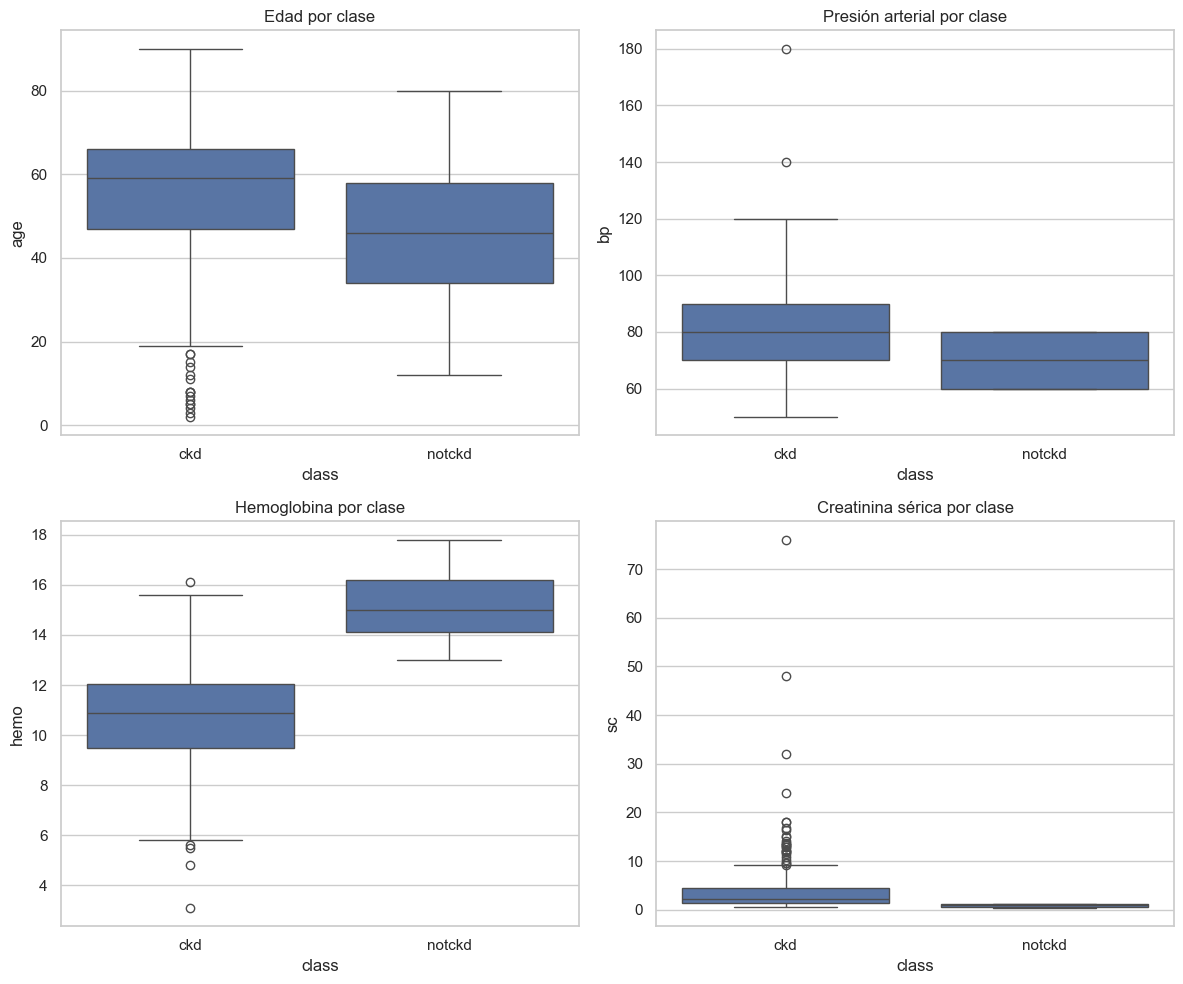

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(x="class", y="age", data=data, ax=axes[0, 0])
axes[0, 0].set_title("Edad por clase")

sns.boxplot(x="class", y="bp", data=data, ax=axes[0, 1])
axes[0, 1].set_title("Presión arterial por clase")

sns.boxplot(x="class", y="hemo", data=data, ax=axes[1, 0])
axes[1, 0].set_title("Hemoglobina por clase")

sns.boxplot(x="class", y="sc", data=data, ax=axes[1, 1])
axes[1, 1].set_title("Creatinina sérica por clase")

plt.tight_layout()
plt.show()

**Interpretación:**  
Los boxplots permiten comparar la distribución de variables numéricas entre las categorías de la variable objetivo `class`. Estas gráficas ayudan a identificar si existen diferencias visibles entre pacientes con enfermedad renal crónica y pacientes sin ella.

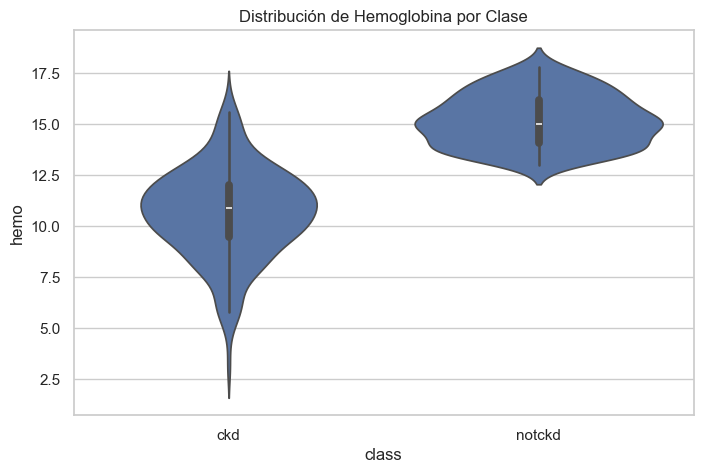

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot hemo distribution based on class status using a violin plot
sns.violinplot(x="class", y="hemo", data=data)
plt.title("Distribución de Hemoglobina por Clase")
plt.show()

**Interpretación:**  
El violinplot permite observar la distribución de la hemoglobina según la variable objetivo `class`. Se aprecia que los pacientes `notckd` presentan valores de hemoglobina más altos y concentrados, mientras que los pacientes `ckd` muestran valores más bajos y una mayor dispersión. Esto sugiere que la hemoglobina es una variable útil para diferenciar entre ambas clases.

In [13]:
data.groupby("class")["hemo"].mean()

class
ckd       10.647549
notckd    15.188194
Name: hemo, dtype: float64

**Interpretación:**  
El promedio de hemoglobina por clase permite cuantificar la diferencia observada en las gráficas. Si el grupo `notckd` presenta una media más alta que `ckd`, esto refuerza la idea de que la hemoglobina puede ayudar a distinguir entre pacientes con y sin enfermedad renal crónica.

In [14]:
data.groupby("class")[["age", "bp", "hemo", "sc"]].agg(["mean", "median", "std"])

age                           bp                         hemo  \
             mean median        std       mean median        std       mean   
class                                                                         
ckd     54.541322   59.0  17.388899  79.625000   80.0  15.234053  10.647549   
notckd  46.516779   46.0  15.631138  71.351351   70.0   8.543498  15.188194   

                               sc                   
       median       std      mean median       std  
class                                               
ckd      10.9  2.185790  4.414916   2.25  6.950275  
notckd   15.0  1.277536  0.868966   0.90  0.255092

**Interpretación:**  
La tabla resume estadísticas descriptivas de variables numéricas relevantes según la clase. Esto permite comparar de forma más precisa diferencias entre pacientes `ckd` y `notckd`, complementando lo observado en las gráficas.

In [15]:
data.groupby("class")[["age", "bp", "hemo", "sc"]].mean()

,age,bp,hemo,sc
class,,,,
ckd,54.541322,79.625000,10.647549,4.414916
notckd,46.516779,71.351351,15.188194,0.868966


**Interpretación:**  
La tabla muestra los promedios de variables numéricas relevantes según la clase. Se observan diferencias entre pacientes `ckd` y `notckd`, especialmente en variables como hemoglobina y creatinina sérica, lo que refuerza lo observado en las gráficas anteriores.

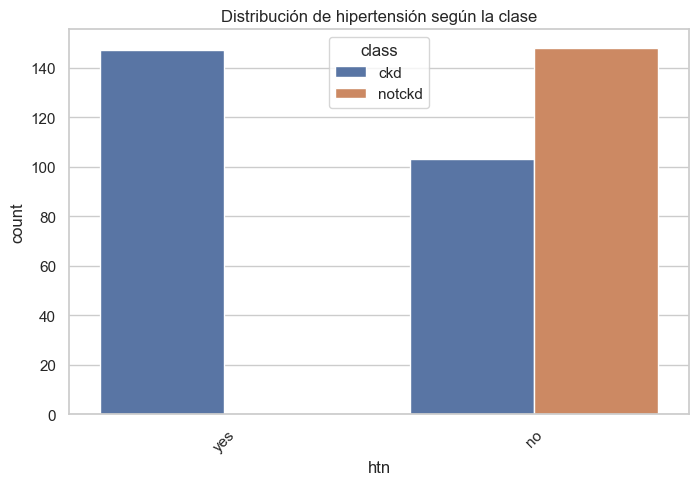

In [16]:
sns.countplot(x="htn", hue="class", data=data)
plt.title("Distribución de hipertensión según la clase")
plt.xticks(rotation=45)
plt.show()

**Interpretación:**  
Esta gráfica permite comparar la distribución de la hipertensión (`htn`) entre las categorías de la variable objetivo `class`. Si una de las clases concentra más pacientes con hipertensión, esto puede sugerir una posible asociación entre ambas variables.

In [17]:
pd.crosstab(data["htn"], data["class"])

class,ckd,notckd
htn,,
no,103,148
yes,147,0


**Interpretación:**  
La tabla resume medidas descriptivas de variables numéricas relevantes según la clase. Esto permite comparar con mayor precisión las diferencias entre pacientes `ckd` y `notckd`, especialmente en variables como hemoglobina y creatinina sérica.


In [18]:
data.groupby("class")[["age", "bp", "hemo", "sc"]].agg(["mean", "median", "std"])

age                           bp                         hemo  \
             mean median        std       mean median        std       mean   
class                                                                         
ckd     54.541322   59.0  17.388899  79.625000   80.0  15.234053  10.647549   
notckd  46.516779   46.0  15.631138  71.351351   70.0   8.543498  15.188194   

                               sc                   
       median       std      mean median       std  
class                                               
ckd      10.9  2.185790  4.414916   2.25  6.950275  
notckd   15.0  1.277536  0.868966   0.90  0.255092

**Interpretación:**  
La tabla de contingencia permite observar con exactitud cuántos pacientes de cada categoría de `htn` pertenecen a cada clase. Esto complementa la visualización gráfica y facilita identificar posibles asociaciones entre hipertensión y enfermedad renal crónica.

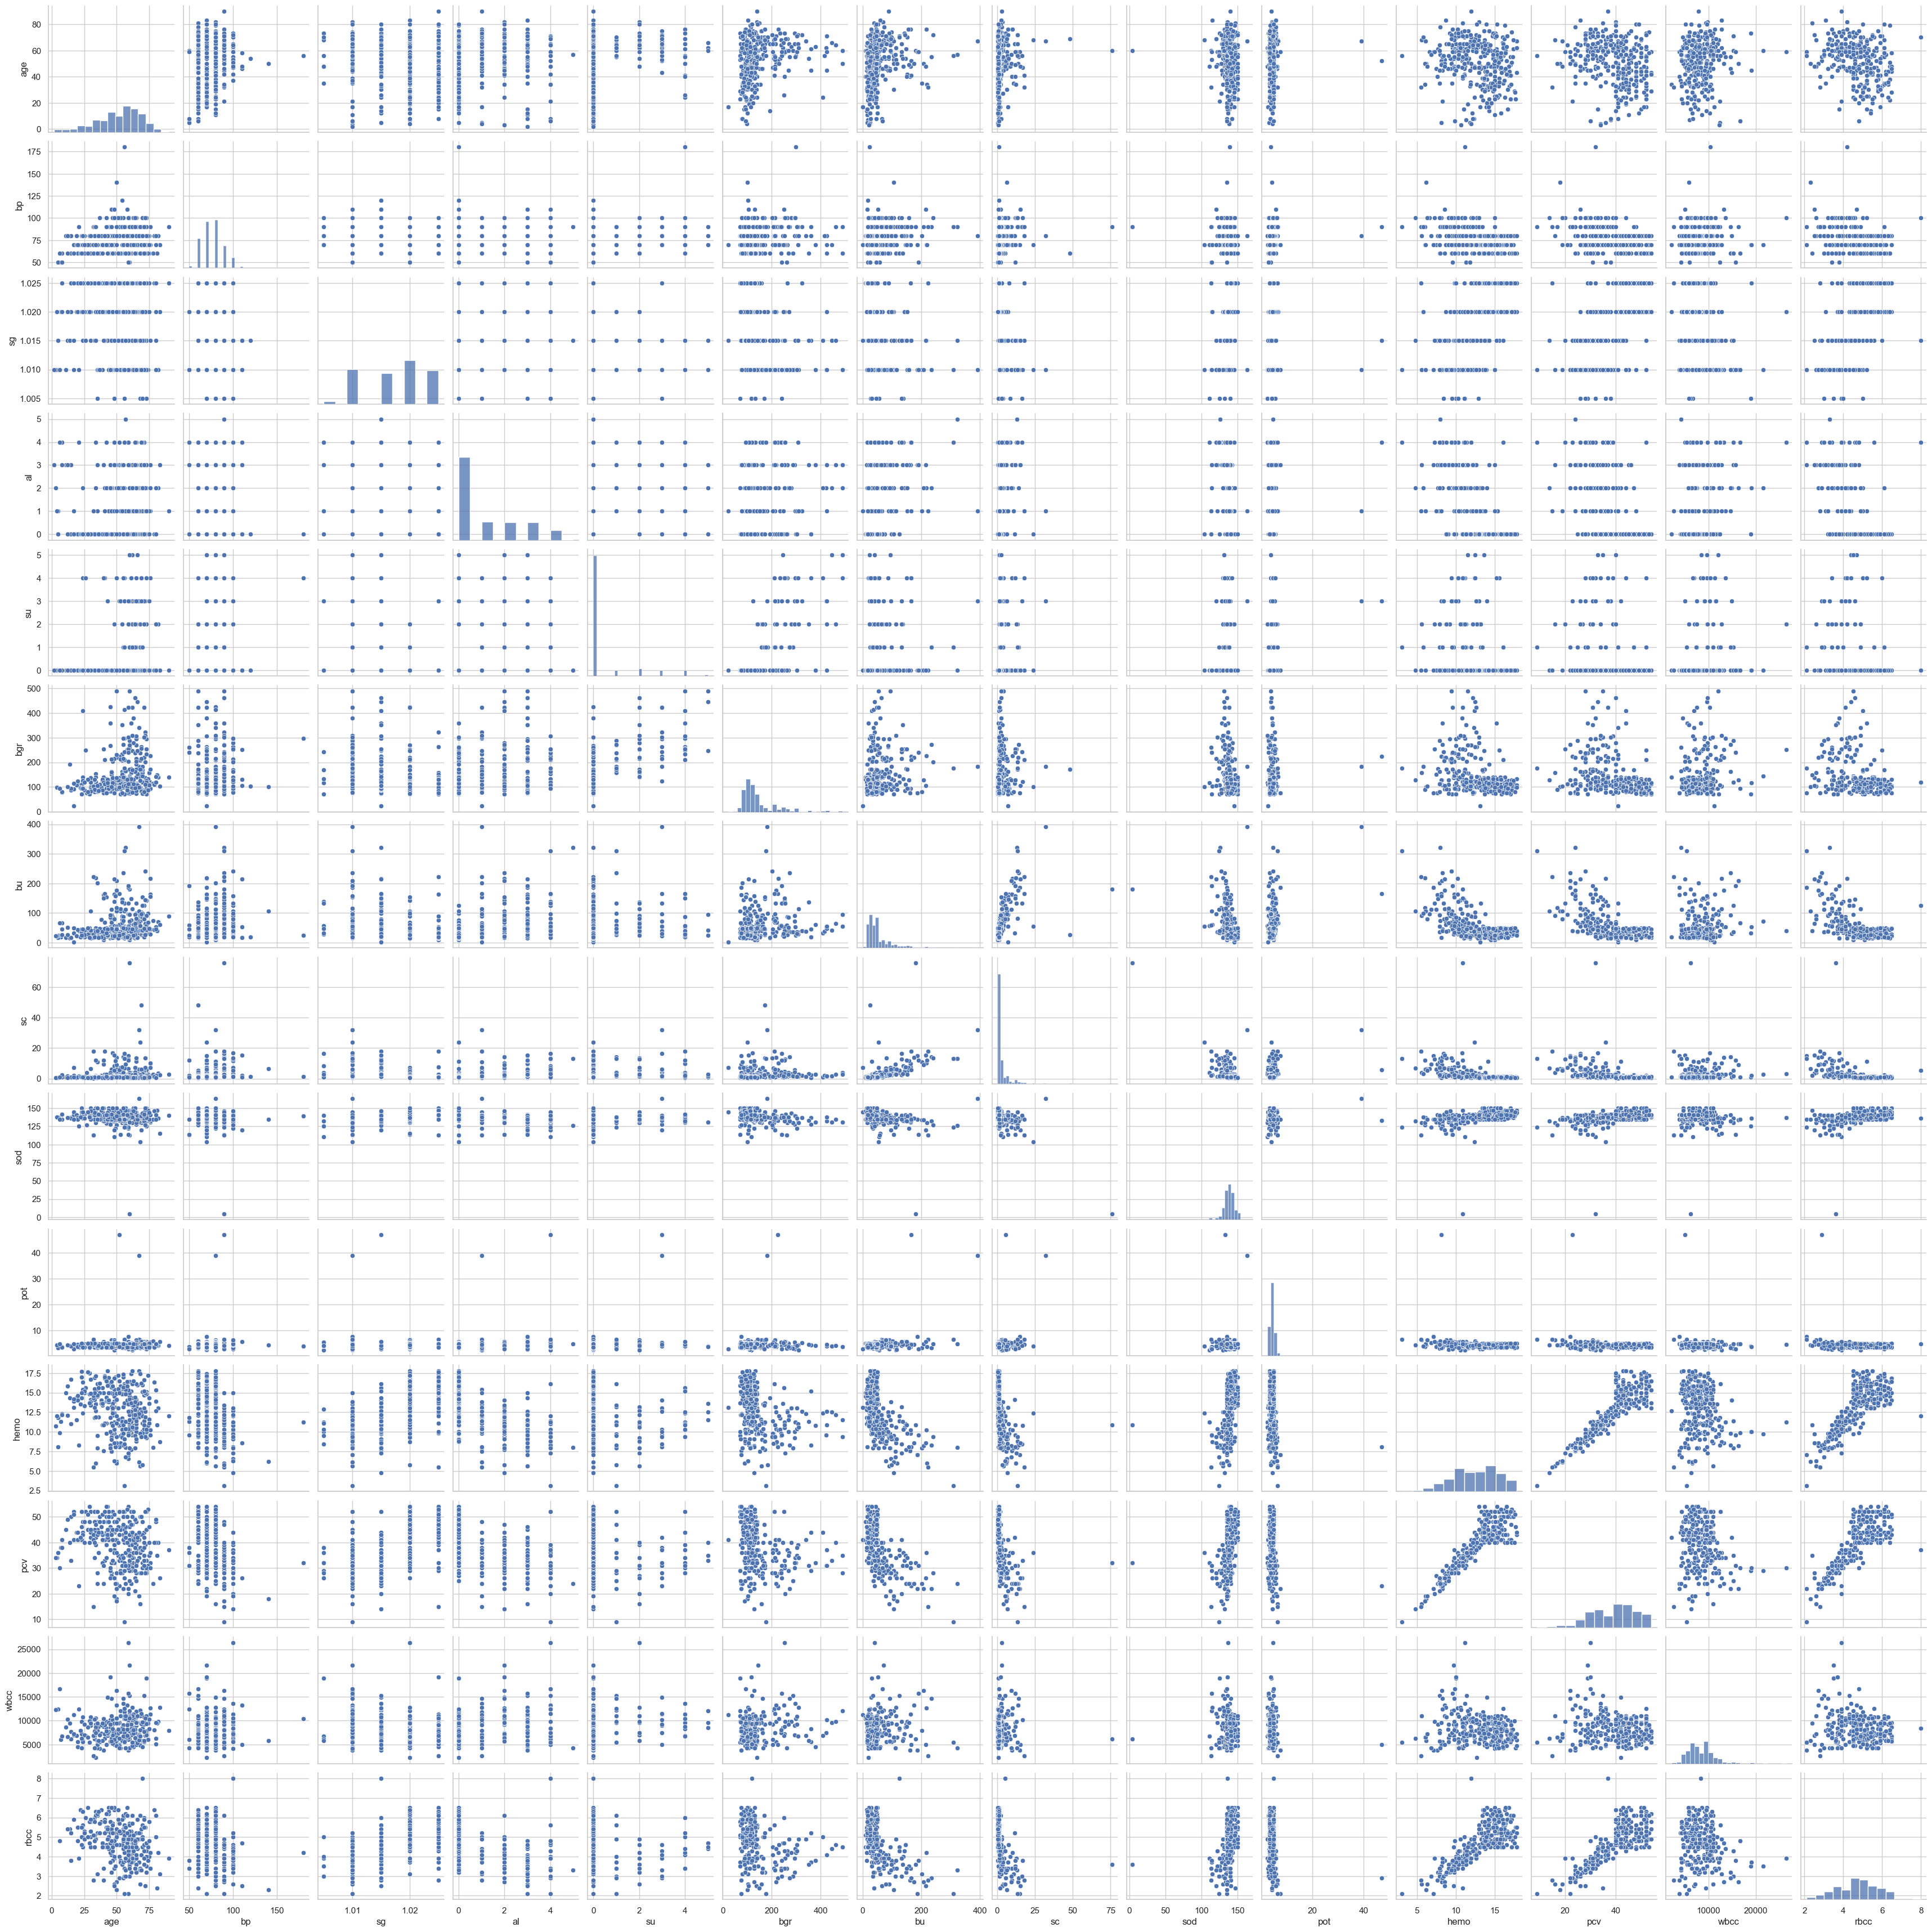

In [19]:
sns.pairplot(data_num)
plt.show()

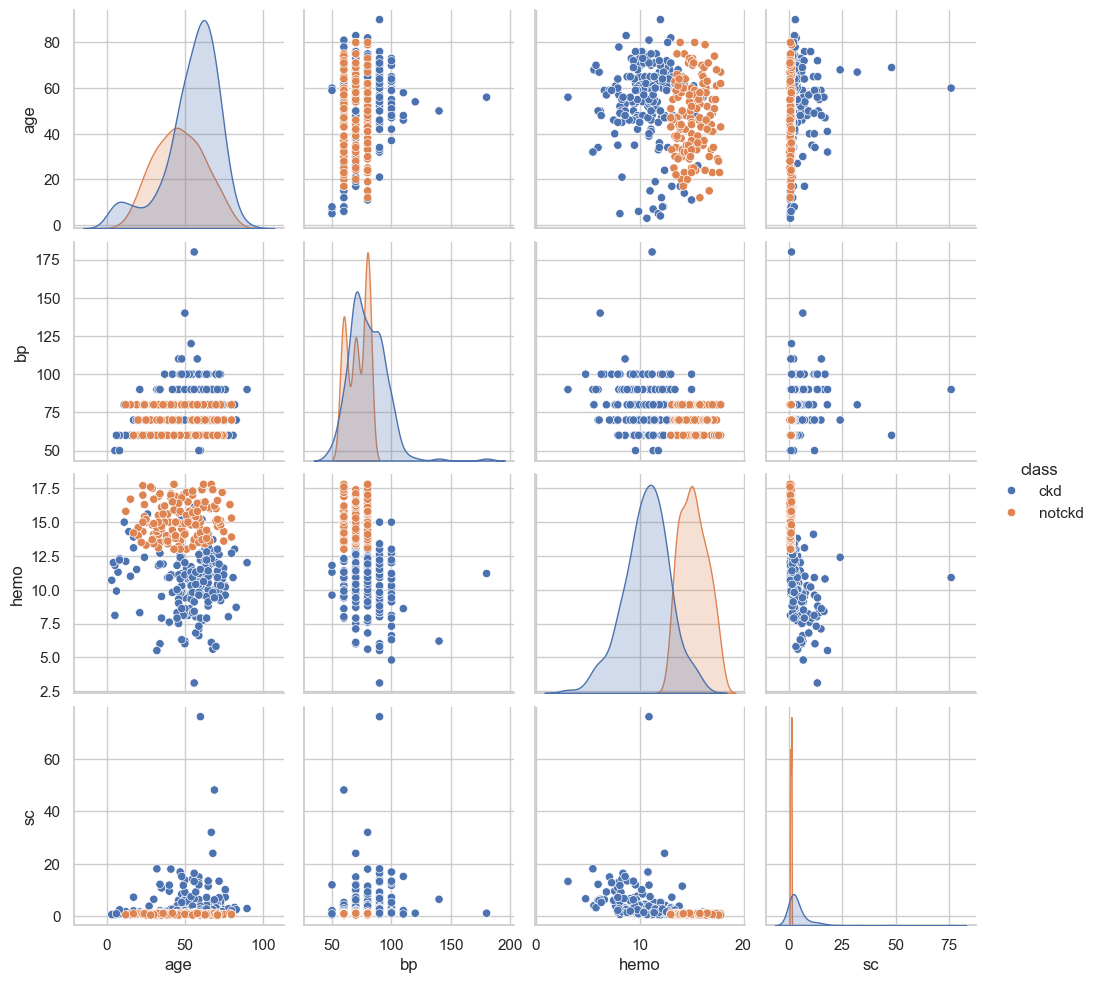

In [20]:
sns.pairplot(data[["age", "bp", "hemo", "sc", "class"]], hue="class")
plt.show()

**Interpretación:**  
El `pairplot` permite visualizar simultáneamente la distribución individual de las variables numéricas y las relaciones bivariadas entre ellas, diferenciando los pacientes según la variable objetivo `class`.

En las gráficas se observa que algunas variables presentan una separación visual entre las clases `ckd` y `notckd`. En particular, la hemoglobina (`hemo`) muestra valores generalmente más altos en los pacientes `notckd`, mientras que los pacientes `ckd` tienden a presentar valores más bajos. De forma similar, la creatinina sérica (`sc`) muestra una diferencia clara entre grupos, ya que los pacientes `ckd` concentran valores más altos y mayor dispersión, mientras que los `notckd` se agrupan en valores bajos.

La variable `age` sugiere cierta diferencia entre clases, aunque con mayor solapamiento, y la presión arterial (`bp`) presenta separación más débil. En general, el gráfico sugiere que variables como `hemo` y `sc` podrían ser especialmente útiles para distinguir entre pacientes con y sin enfermedad renal crónica.

### 7. Distribución de la variable objetivo
En esta gráfica se observa la frecuencia de las categorías de la variable objetivo `class`.

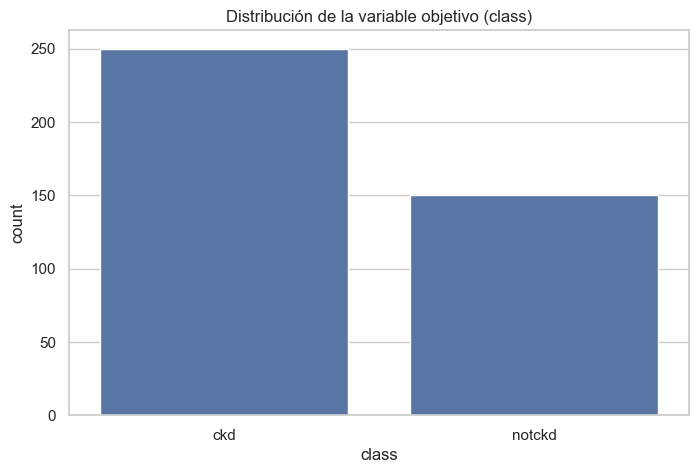

In [21]:
sns.countplot(x="class", data=data)
plt.title("Distribución de la variable objetivo (class)")
plt.show()

**Interpretación:**  
La variable objetivo presenta dos categorías: `ckd` y `notckd`. La gráfica permite identificar si la base está balanceada o si una clase tiene mayor frecuencia que la otra.

In [22]:
# Analizar el Desbalanceo #
data["class"].value_counts(normalize=True)

class
ckd       0.625
notckd    0.375
Name: proportion, dtype: float64

**Interpretación:**  
La distribución relativa de la variable objetivo permite evaluar si la base está balanceada o desbalanceada. En este caso, la clase `ckd` representa una mayor proporción que `notckd`, por lo que existe un desbalance moderado entre las categorías.

## 8. Hallazgos principales del análisis exploratorio

- La base de clasificación contiene variables numéricas y categóricas.
- La variable objetivo `class` presenta dos categorías: `ckd` y `notckd`.
- La clase no está completamente balanceada, ya que hay más registros de `ckd` que de `notckd`.
- Las variables numéricas presentan diferentes niveles de dispersión y algunos posibles valores atípicos.
- En los boxplots por clase se observan diferencias visibles en variables como edad, presión arterial, hemoglobina y creatinina sérica.
- La matriz de correlación permite identificar relaciones lineales entre algunas variables numéricas, lo que puede ser útil en etapas posteriores del análisis.

### 9. DATOS FALTANTES

In [23]:
# Ver primeras filas
print(data.head())

# Información general
print(data.info())

# Conteo de valores nulos por columna
print("\nValores nulos por columna:")
print(data.isnull().sum())

# Porcentaje de valores nulos
print("\nPorcentaje de valores nulos por columna:")
print((data.isnull().sum()/len(data))*100)

    age    bp     sg   al   su     rbc        pc         pcc          ba  \
0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

     bgr    bu   sc    sod  pot  hemo   pcv    wbcc  rbcc  htn   dm cad appet  \
0  121.0  36.0  1.2    NaN  NaN  15.4  44.0  7800.0   5.2  yes  yes  no  good   
1    NaN  18.0  0.8    NaN  NaN  11.3  38.0  6000.0   NaN   no   no  no  good   
2  423.0  53.0  1.8    NaN  NaN   9.6  31.0  7500.0   NaN   no  yes  no  poor   
3  117.0  56.0  3.8  111.0  2.5  11.2  32.0  6700.0   3.9  yes   no  no  poor   
4  106.0  26.0  1.4    NaN  NaN  11.6  35.0  7300.0   4.6   no   no  no  good   

    pe  ane class  
0   no   no   ckd  
1   no   no   ck

# 9.1 Separación de variables numéricas y categóricas

In [24]:
numericas = data.select_dtypes(include=["number"]).columns.tolist()
categoricas = data.select_dtypes(exclude=["number"]).columns.tolist()

print("Variables numéricas:", numericas)
print("Variables categóricas:", categoricas)

Variables numéricas: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Variables categóricas: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


# 9.2 Método 1: Imputación por medidas de tendencia central
- Para númericas: Mediana
- Para Cateóricas: Moda

In [25]:
from sklearn.impute import SimpleImputer

# Copia de la base
data_imputada_simple = data.copy()

# Imputación numérica con mediana
imputer_num = SimpleImputer(strategy="median")
data_imputada_simple[numericas] = imputer_num.fit_transform(data[numericas])

# Imputación categórica con moda
imputer_cat = SimpleImputer(strategy="most_frequent")
data_imputada_simple[categoricas] = imputer_cat.fit_transform(data[categoricas])

print("Valores nulos después de imputación simple:")
print(data_imputada_simple.isnull().sum())

Valores nulos después de imputación simple:
age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64


# 9.3 Método 2: Imputación KNN
La imputación KNN se aplica sobre variables numéricas.
Para categóricas, usamos moda.

In [26]:
from sklearn.impute import KNNImputer

# Copia de la base
data_imputada_knn = data.copy()

# Imputación categórica primero con moda
imputer_cat = SimpleImputer(strategy="most_frequent")
data_imputada_knn[categoricas] = imputer_cat.fit_transform(data[categoricas])

# Imputación numérica con KNN
imputer_knn = KNNImputer(n_neighbors=5)
data_imputada_knn[numericas] = imputer_knn.fit_transform(data[numericas])

print("Valores nulos después de imputación KNN:")
print(data_imputada_knn.isnull().sum())

Valores nulos después de imputación KNN:
age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64


# 9.4 Método 3: Imputación Iterativa
También aplica a variables numéricas.
Para categóricas, nuevamente usamos moda.

In [27]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Copia de la base
data_imputada_iter = data.copy()

# Imputación categórica con moda
imputer_cat = SimpleImputer(strategy="most_frequent")
data_imputada_iter[categoricas] = imputer_cat.fit_transform(data[categoricas])

# Imputación numérica iterativa
imputer_iter = IterativeImputer(random_state=42)
data_imputada_iter[numericas] = imputer_iter.fit_transform(data[numericas])

print("Valores nulos después de imputación iterativa:")
print(data_imputada_iter.isnull().sum())

Valores nulos después de imputación iterativa:
age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64


# 9.5 Comparar antes y después de la imputación

In [28]:
print("=== Base original ===")
print(data[numericas].describe())

print("\n=== Imputación simple ===")
print(data_imputada_simple[numericas].describe())

print("\n=== Imputación KNN ===")
print(data_imputada_knn[numericas].describe())

print("\n=== Imputación iterativa ===")
print(data_imputada_iter[numericas].describe())

=== Base original ===
              age          bp          sg          al          su         bgr  \
count  391.000000  388.000000  353.000000  354.000000  351.000000  356.000000   
mean    51.483376   76.469072    1.017408    1.016949    0.450142  148.036517   
std     17.169714   13.683637    0.005717    1.352679    1.099191   79.281714   
min      2.000000   50.000000    1.005000    0.000000    0.000000   22.000000   
25%     42.000000   70.000000    1.010000    0.000000    0.000000   99.000000   
50%     55.000000   80.000000    1.020000    0.000000    0.000000  121.000000   
75%     64.500000   80.000000    1.020000    2.000000    0.000000  163.000000   
max     90.000000  180.000000    1.025000    5.000000    5.000000  490.000000   

               bu          sc         sod         pot        hemo         pcv  \
count  381.000000  383.000000  313.000000  312.000000  348.000000  329.000000   
mean    57.425722    3.072454  137.528754    4.627244   12.526437   38.884498   
std  

# 9.6 Comparar valores nulos antes y después

In [29]:
comparacion_nulos = pd.DataFrame({
    "Original": data.isnull().sum(),
    "Simple": data_imputada_simple.isnull().sum(),
    "KNN": data_imputada_knn.isnull().sum(),
    "Iterativa": data_imputada_iter.isnull().sum()
})

print(comparacion_nulos)

       Original  Simple  KNN  Iterativa
age           9       0    0          0
bp           12       0    0          0
sg           47       0    0          0
al           46       0    0          0
su           49       0    0          0
rbc         152       0    0          0
pc           65       0    0          0
pcc           4       0    0          0
ba            4       0    0          0
bgr          44       0    0          0
bu           19       0    0          0
sc           17       0    0          0
sod          87       0    0          0
pot          88       0    0          0
hemo         52       0    0          0
pcv          71       0    0          0
wbcc        106       0    0          0
rbcc        131       0    0          0
htn           2       0    0          0
dm            2       0    0          0
cad           2       0    0          0
appet         1       0    0          0
pe            1       0    0          0
ane           1       0    0          0


## 9.7 Metodo de imputacion más adecuado


## 9.7.1 Comparacion de distribuciones

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# =========================
# 2. Identificar variables numéricas y categóricas
# =========================
numericas = data.select_dtypes(include=["number"]).columns.tolist()
categoricas = data.select_dtypes(exclude=["number"]).columns.tolist()

print("Variables numéricas:", numericas)
print("Variables categóricas:", categoricas)

# =========================
# 3. Base con faltantes reales
# =========================
data_faltantes = data.copy()

print("\nValores nulos por columna:")
print(data_faltantes.isnull().sum())

# =========================
# 4. Imputación simple
# =========================
data_simple = data_faltantes.copy()

if numericas:
    imp_num_simple = SimpleImputer(strategy="median")
    data_simple[numericas] = imp_num_simple.fit_transform(data_faltantes[numericas])

if categoricas:
    imp_cat_simple = SimpleImputer(strategy="most_frequent")
    data_simple[categoricas] = imp_cat_simple.fit_transform(data_faltantes[categoricas])

# =========================
# 5. Imputación KNN
# =========================
data_knn = data_faltantes.copy()

if categoricas:
    imp_cat_knn = SimpleImputer(strategy="most_frequent")
    data_knn[categoricas] = imp_cat_knn.fit_transform(data_faltantes[categoricas])

if numericas:
    imp_knn = KNNImputer(n_neighbors=5)
    data_knn[numericas] = imp_knn.fit_transform(data_faltantes[numericas])

# =========================
# 6. Imputación iterativa
# =========================
data_iter = data_faltantes.copy()

if categoricas:
    imp_cat_iter = SimpleImputer(strategy="most_frequent")
    data_iter[categoricas] = imp_cat_iter.fit_transform(data_faltantes[categoricas])

if numericas:
    imp_iter = IterativeImputer(random_state=42)
    data_iter[numericas] = imp_iter.fit_transform(data_faltantes[numericas])

print("\nImputación terminada correctamente.")

Variables numéricas: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Variables categóricas: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']

Valores nulos por columna:
age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

Imputación terminada correctamente.


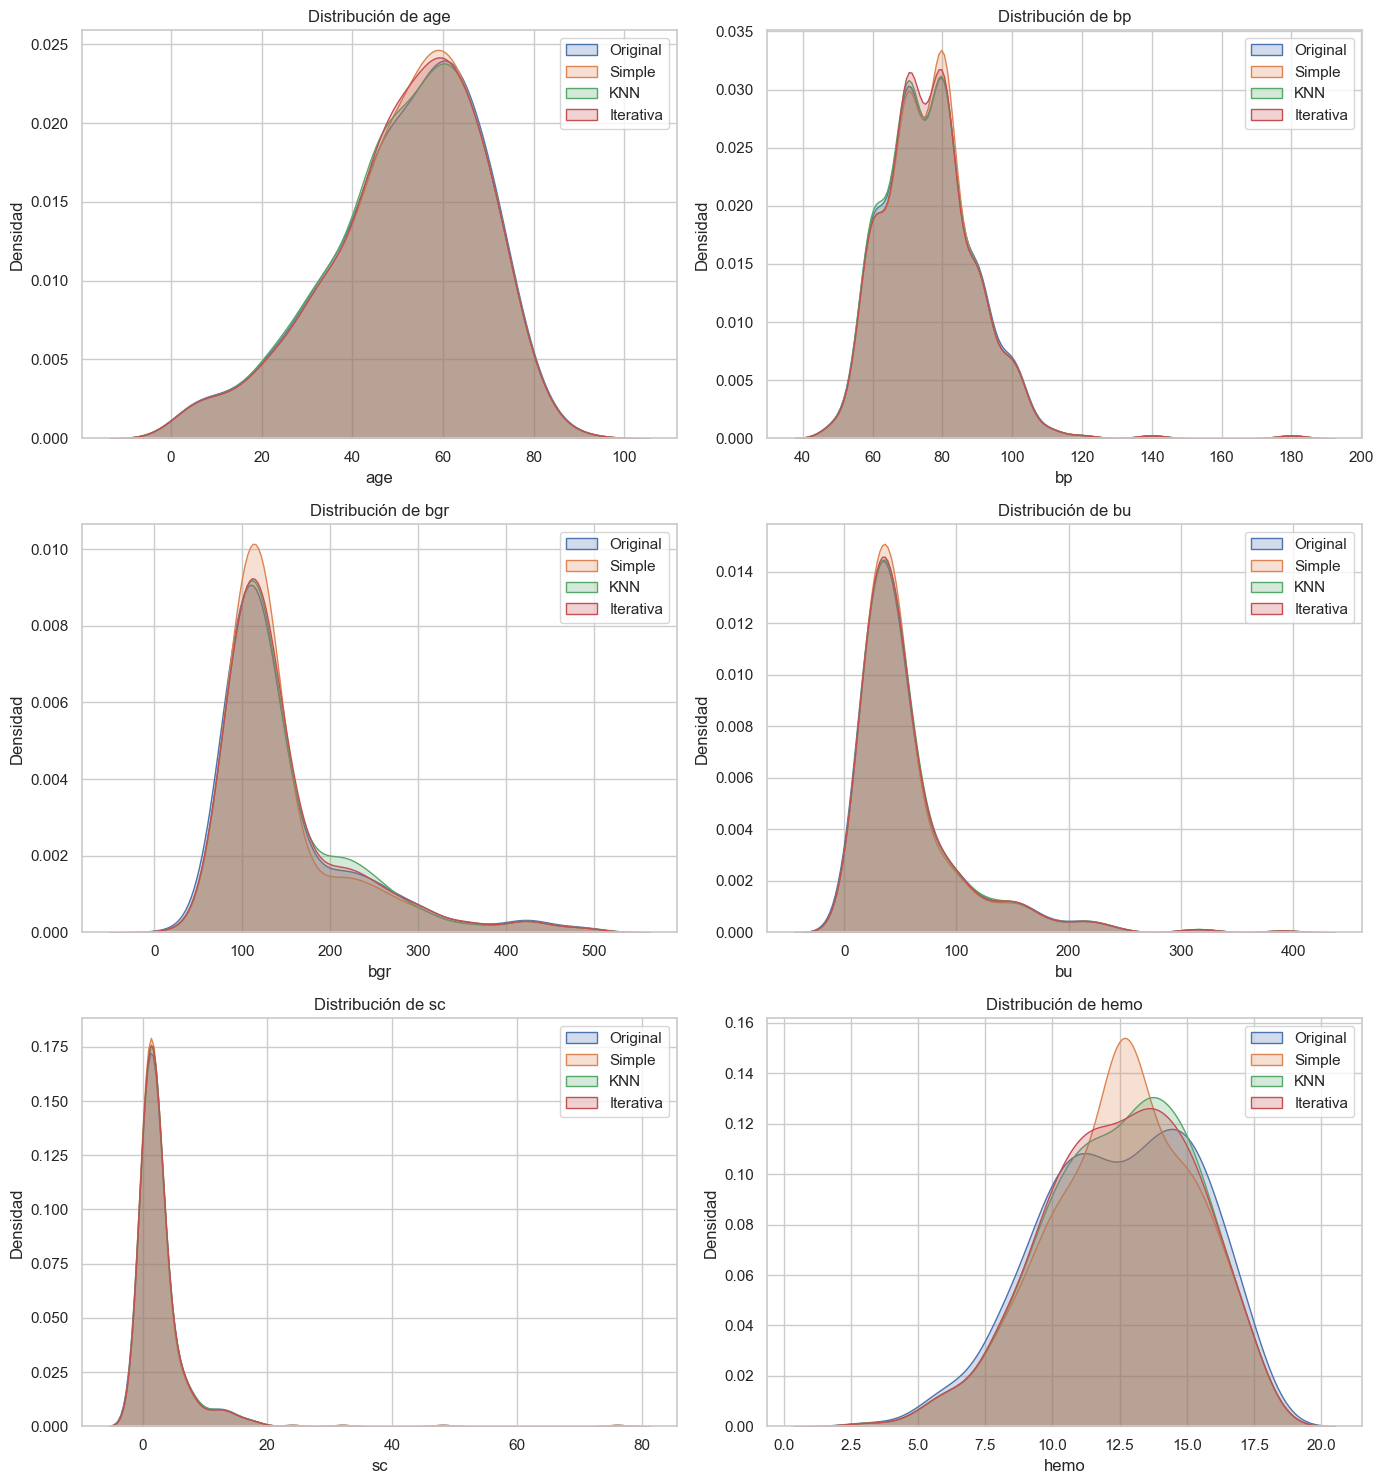

In [31]:
variables_importantes = ["age", "bp", "bgr", "bu", "sc", "hemo"]

n = len(variables_importantes)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

for i, variable in enumerate(variables_importantes):
    if variable in numericas:
        sns.kdeplot(data[variable].dropna(), label="Original", fill=True, ax=axes[i])
        sns.kdeplot(data_simple[variable], label="Simple", fill=True, ax=axes[i])
        sns.kdeplot(data_knn[variable], label="KNN", fill=True, ax=axes[i])
        sns.kdeplot(data_iter[variable], label="Iterativa", fill=True, ax=axes[i])

        axes[i].set_title(f"Distribución de {variable}")
        axes[i].set_xlabel(variable)
        axes[i].set_ylabel("Densidad")
        axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 9.7.2 boxplot comparativo

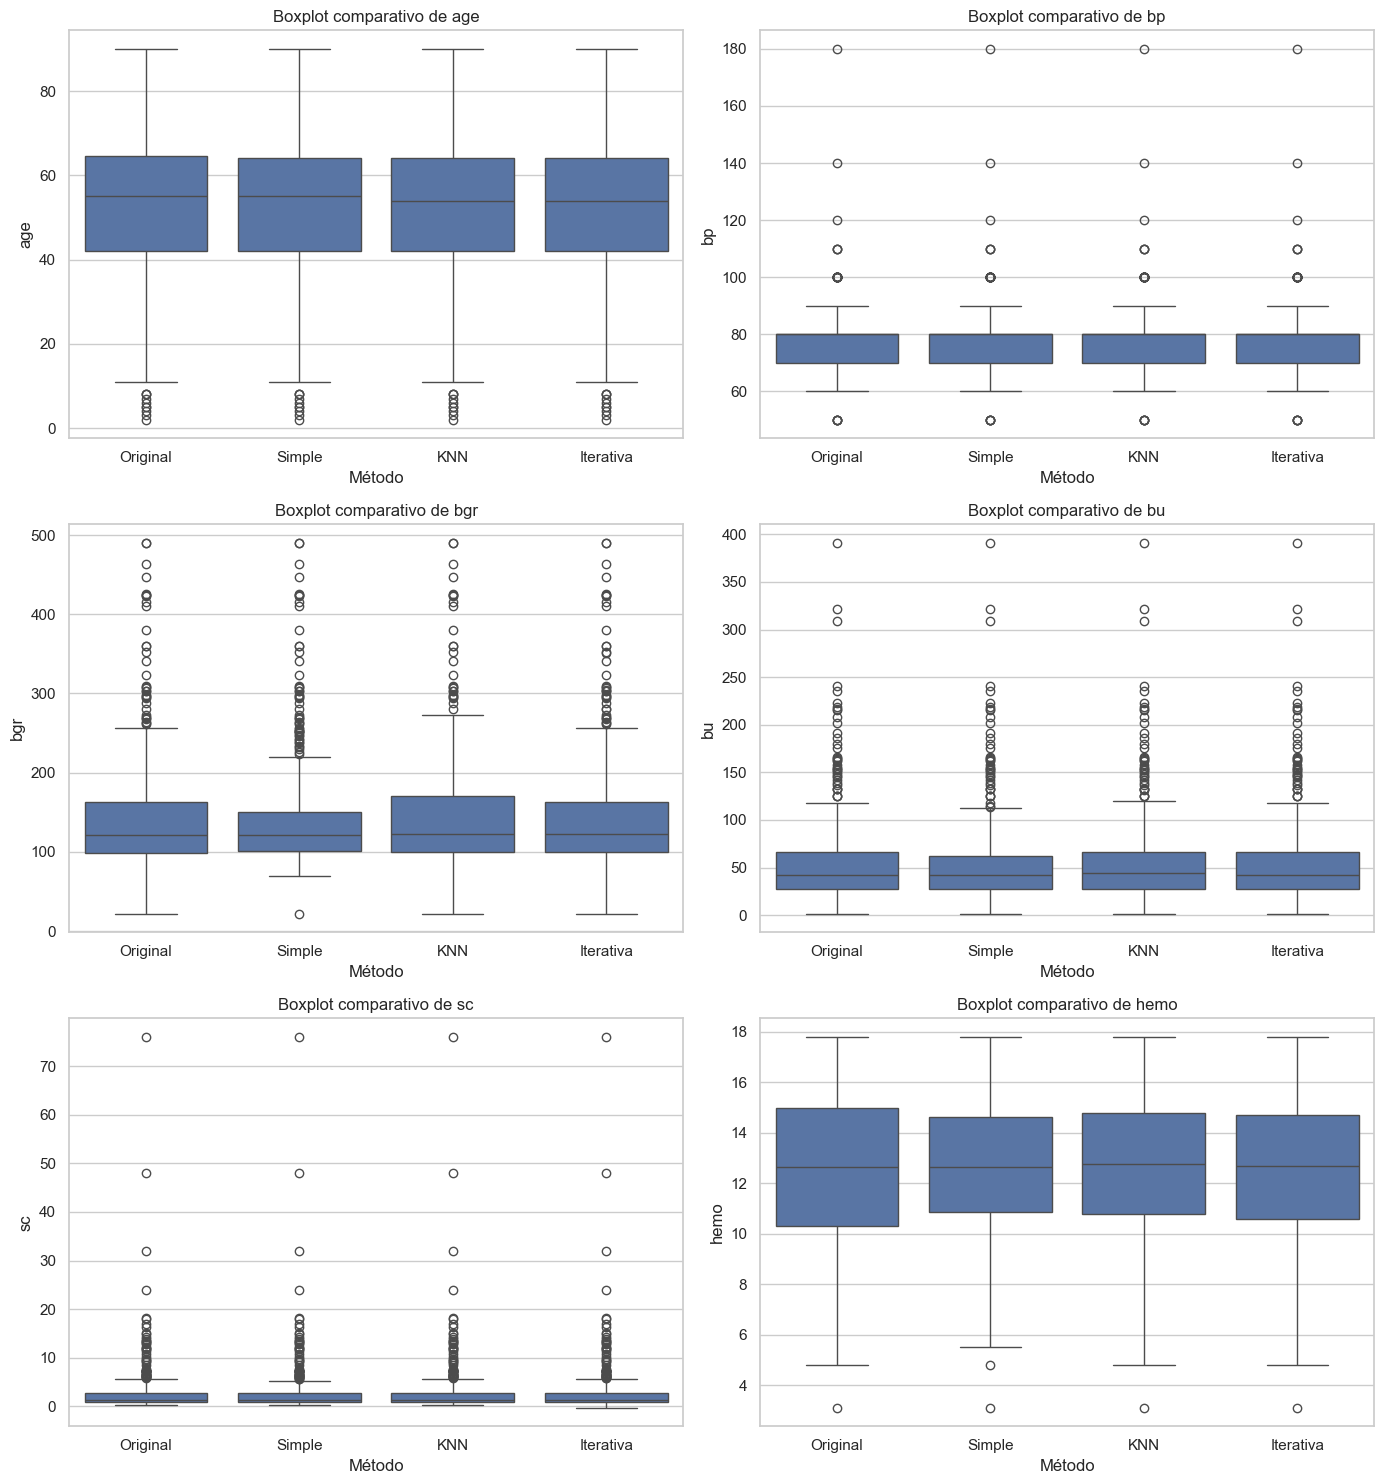

In [32]:
variables_importantes = ["age", "bp", "bgr", "bu", "sc", "hemo"]

n = len(variables_importantes)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

for i, variable in enumerate(variables_importantes):
    if variable in numericas:
        df_long = pd.concat([
            pd.DataFrame({"Metodo": "Original", "Valor": data[variable].dropna()}),
            pd.DataFrame({"Metodo": "Simple", "Valor": data_simple[variable]}),
            pd.DataFrame({"Metodo": "KNN", "Valor": data_knn[variable]}),
            pd.DataFrame({"Metodo": "Iterativa", "Valor": data_iter[variable]})
        ])

        sns.boxplot(data=df_long, x="Metodo", y="Valor", ax=axes[i])
        axes[i].set_title(f"Boxplot comparativo de {variable}")
        axes[i].set_xlabel("Método")
        axes[i].set_ylabel(variable)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A partir de los gráficos de densidad y boxplots, se observa que el método KNN es el que mejor conserva la forma de la distribución original de las variables, manteniendo tanto la dispersión como la presencia de valores atípicos de manera coherente. La imputación simple tiende a concentrar los datos alrededor de la mediana, reduciendo la variabilidad, mientras que la imputación iterativa introduce ligeras distorsiones y posibles valores menos realistas. En contraste, KNN logra un equilibrio adecuado entre preservar la estructura original de los datos y evitar alteraciones significativas, por lo que se concluye que es el método más apropiado para esta base de datos.


## 9.8 Pruebas de asociación y dependencia

### 9.8.1 Variables categóricas: prueba Chi-cuadrado
En esta sección se evalúa si existe asociación entre la variable categórica `htn` y la variable objetivo `class` mediante la prueba Chi-cuadrado.

In [33]:
from scipy.stats import chi2_contingency

tabla_htn_class = pd.crosstab(data["htn"], data["class"])
tabla_htn_class

class,ckd,notckd
htn,,
no,103,148
yes,147,0


In [34]:
chi2, p, dof, expected = chi2_contingency(tabla_htn_class)

print("Chi-cuadrado:", chi2)
print("p-valor:", p)
print("Grados de libertad:", dof)
print("Frecuencias esperadas:")
print(expected)

Chi-cuadrado: 135.47742554474144
p-valor: 2.5960250186669087e-31
Grados de libertad: 1
Frecuencias esperadas:
[[157.66331658  93.33668342]
 [ 92.33668342  54.66331658]]


**Interpretación:**  
La prueba Chi-cuadrado aplicada entre `htn` y `class` arrojó un estadístico de 135.48 y un p-valor de 2.5960250186669087e-31. Como el p-valor es mucho menor que 0.05, se rechaza la hipótesis nula de independencia y se concluye que existe una asociación estadísticamente significativa entre la hipertensión (`htn`) y la variable objetivo `class`.

En esta base de datos, esto indica que la presencia o ausencia de hipertensión está relacionada con la clasificación de los pacientes entre `ckd` y `notckd`. Por tanto, `htn` es una variable categórica relevante dentro del análisis de dependencia para el problema de clasificación.

Además, las frecuencias esperadas son todas mayores que 5, por lo que la aplicación de la prueba Chi-cuadrado es adecuada en este caso.

### 9.8.2 Variables numéricas: correlación de Spearman
En esta sección se evalúa la dependencia entre las variables numéricas `hemo` (hemoglobina) y `sc` (creatinina sérica) mediante la correlación de Spearman.

In [35]:
from scipy.stats import spearmanr

subset = data[["hemo", "sc"]].dropna()

rho, p = spearmanr(subset["hemo"], subset["sc"])

print("Coeficiente de Spearman:", rho)
print("p-valor:", p)

Coeficiente de Spearman: -0.7264628007413281
p-valor: 1.5878739726740626e-56


**Interpretación:**  
La correlación de Spearman entre `hemo` (hemoglobina) y `sc` (creatinina sérica) produjo un coeficiente de -0.7265 y un p-valor de 1.5878739726740975e-56. Como el p-valor es mucho menor que 0.05, se concluye que existe una relación estadísticamente significativa entre ambas variables.

El coeficiente negativo indica que la relación es inversa: a medida que aumenta la creatinina sérica, la hemoglobina tiende a disminuir. Además, como la magnitud del coeficiente es alta, la asociación monotónica entre estas variables puede considerarse fuerte. En esta base de datos, esto sugiere que `hemo` y `sc` presentan una dependencia importante y que ambas pueden aportar información relevante en el análisis de la enfermedad renal crónica.

### 9.8.3 Variables mixtas: prueba Kruskal-Wallis
En esta sección se evalúa si existen diferencias significativas en la variable numérica `hemo` según las categorías de la variable `class`, mediante la prueba de Kruskal-Wallis.

In [36]:
from scipy.stats import kruskal

grupo_ckd = data[data["class"] == "ckd"]["hemo"].dropna()
grupo_notckd = data[data["class"] == "notckd"]["hemo"].dropna()

stat, p = kruskal(grupo_ckd, grupo_notckd)

print("Estadístico de Kruskal-Wallis:", stat)
print("p-valor:", p)

Estadístico de Kruskal-Wallis: 222.0050946335994
p-valor: 3.303924636777283e-50


**Interpretación:**  
La prueba de Kruskal-Wallis aplicada a la variable `hemo` según las categorías de `class` produjo un estadístico de 222.01 y un p-valor de 3.303924636777283e-50. Como el p-valor es mucho menor que 0.05, se concluye que existen diferencias estadísticamente significativas en los valores de hemoglobina entre los grupos `ckd` y `notckd`.

En esta base de datos, esto indica que la variable numérica `hemo` depende de la categoría de la variable `class`, por lo que la hemoglobina resulta relevante para diferenciar entre pacientes con y sin enfermedad renal crónica.

### 9.8.4 Hallazgos principales de las pruebas estadísticas

- La prueba Chi-cuadrado mostró una asociación significativa entre `htn` y `class`, lo que indica que la hipertensión está relacionada con la clasificación de los pacientes.
- La correlación de Spearman entre `hemo` y `sc` fue negativa y fuerte, mostrando que a mayores valores de creatinina sérica tienden a observarse menores niveles de hemoglobina.
- La prueba de Kruskal-Wallis evidenció diferencias significativas en la variable `hemo` entre los grupos `ckd` y `notckd`.
- En conjunto, los resultados indican que existen relaciones de dependencia relevantes entre variables categóricas, numéricas y mixtas dentro de la base de clasificación.